In [1]:
import io
import textwrap

import beaker
import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting
import utils

In [2]:
def open_beaker_dataset(dataset_id: str, path: str, variables=None) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    if variables is None:
        return xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    else:
        return xr.open_dataset(io.BytesIO(file), engine="h5netcdf")[variables].load()

In [3]:
TEMPLATE = "2026-09-09-{model}-abrupt-4xCO2-evaluator"

WANDB_CASES = {
    "SHiELD-SOM": utils.wandb_id_from_name("2026-03-23-abrupt-4xCO2-data-only-evaluator"),
    "ACE2-SOM baseline": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3")),
    # "no-random-co2 non-energy-conserving rs0": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs0")),
    # "no-random-co2 non-energy-conserving rs1": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs1")),
    "no-random-co2 energy-conserving rs0": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0")),
    "no-random-co2 energy-conserving rs1": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1")),
    # "full non-energy-conserving rs0": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs0")),
    # "full non-energy-conserving rs1": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs1")),
    "full energy-conserving rs0": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0")),
    "full energy-conserving rs1": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1")),
    "full baseline-like rs0": utils.wandb_id_from_name(TEMPLATE.format(model="baseline-like-full-rs0")),
    # "full baseline-like rs1": utils.wandb_id_from_name(TEMPLATE.format(model="baseline-like-full-rs1")),
}
BEAKER_CASES = {
    "SHiELD-SOM": utils.beaker_dataset_id_from_name("2026-03-23-abrupt-4xCO2-data-only-evaluator"),
    "ACE2-SOM baseline": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="published-baseline-rs3")),
    # "no-random-co2 non-energy-conserving rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-rs0")),
    # "no-random-co2 non-energy-conserving rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-rs1")),
    "no-random-co2 energy-conserving rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0")),
    "no-random-co2 energy-conserving rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1")),
    # "full non-energy-conserving rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-rs0")),
    # "full non-energy-conserving rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-rs1")),
    "full energy-conserving rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0")),
    "full energy-conserving rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1")),
    "full baseline-like rs0": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="baseline-like-full-rs0")),
    # "full baseline-like rs1": utils.beaker_dataset_id_from_name(TEMPLATE.format(model="baseline-like-full-rs1")),
}
NETCDF = "monthly_mean_predictions.nc"

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Experiment'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/hom

In [4]:
ace2_som = open_beaker_dataset(BEAKER_CASES["ACE2-SOM baseline"], NETCDF)
full = open_beaker_dataset(BEAKER_CASES["full energy-conserving rs0"], NETCDF)

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01KP6SETJ7CAHF1Y38AAZRZFY9' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

In [5]:
REFERENCE = "gs://vcm-ml-raw-flexible-retention/2024-07-03-C96-SHiELD-SOM/regridded-zarrs/gaussian_grid_180_by_360/1xCO2-ic_0001/full_state.zarr"
RENAME = {
    "grid_xt": "lon",
    "grid_yt": "lat",
    "grid_xt_bnds": "lon_bnds",
    "grid_yt_bnds": "lat_bnds",
}


def isclose(a, b, **kwargs):
    return xr.apply_ufunc(np.isclose, a, b, kwargs=kwargs, dask="parallelized")


def get_ocean_fraction() -> xr.DataArray:
    ds = xr.open_zarr(REFERENCE)
    ds = ds.rename(RENAME)
    return isclose(ds.mean("time").ocean_fraction, 1.0).astype(np.float64)


def get_weights_pure_ocean() -> xr.Dataset:
    land_fraction = xr.open_zarr(REFERENCE).rename(RENAME).land_fraction.isel(time=0)
    ocean_fraction = get_ocean_fraction()
    area_weights = np.cos(np.deg2rad(land_fraction.lat)).broadcast_like(land_fraction)
    return (
        xr.concat(
            [
                area_weights,
                area_weights * land_fraction,
                area_weights * ocean_fraction,
            ],
            dim=pd.Index(["global", "land", "ocean"], name="region"),
        )
        .drop_vars(["lon", "lat"])
        .load()
    )


def load_metrics_from_wandb(run, keys):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    time = xr.date_range("2020-01-01T12:00:00", freq="6h", periods=ds.sizes["time"])
    ds = ds.assign_coords(time=time)
    ds = ds.resample(time="MS").mean()
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})

In [6]:
api = wandb.Api()

In [7]:
VARIABLE_NAMES = ["surface_temperature", "air_temperature_0", "ULWRFtoa"]
METRIC_NAMES = [f"inference/mean/weighted_mean_gen/{var}" for var in VARIABLE_NAMES]

WANDB_ENTITY = "ai2cm"
WANDB_PROJECT = "ace-shield"
ACE_RUNS = {}
for name, id in WANDB_CASES.items():
    ACE_RUNS[name] = api.run(id)

In [8]:
wandb_ds = load_metrics_from_wandb(ACE_RUNS["ACE2-SOM baseline"], METRIC_NAMES)

In [9]:
weights = get_weights_pure_ocean()

In [10]:
LABELS = {
    "SHiELD-SOM": "SHiELD",
    "ACE2-SOM baseline": "ACE2-SOM",
    "no-random-co2 energy-conserving rs0": "ACE2S-SHiELD+$_{\\text{no-RC}}$",
    "no-random-co2 energy-conserving rs1": "ACE2S-SHiELD+$_{\\text{no-RC}}$",
    "full energy-conserving rs0": "ACE2S-SHiELD+",
    "full energy-conserving rs1": "ACE2S-SHiELD+",
}

In [11]:
beaker_datasets = {}
for name, id in BEAKER_CASES.items():
    ds = open_beaker_dataset(id, NETCDF)
    regional_mean = ds.weighted(weights).mean(["lat", "lon"])
    beaker_datasets[name] = regional_mean
beaker_ds = xr.concat(list(beaker_datasets.values()), dim=pd.Index(beaker_datasets.keys(), name="model"))

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [12]:
wandb_datasets = {}
for name, run in ACE_RUNS.items():
    print(name)
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    wandb_datasets[name] = ds
wandb_ds = xr.concat(list(wandb_datasets.values()), dim=pd.Index(wandb_datasets.keys(), name="model"))

SHiELD-SOM
ACE2-SOM baseline
no-random-co2 energy-conserving rs0
no-random-co2 energy-conserving rs1
full energy-conserving rs0
full energy-conserving rs1
full baseline-like rs0


In [13]:
COLORS = {
    "SHiELD-SOM": "k",
    "ACE2-SOM baseline": "C3",
    "no-random-co2 non-energy-conserving rs0": "C1",
    "no-random-co2 non-energy-conserving rs1": "C1",
    "no-random-co2 energy-conserving rs0": "C2",
    "no-random-co2 energy-conserving rs1": "C2",
    "full non-energy-conserving rs0": "C5",
    "full non-energy-conserving rs1": "C5",
    "full energy-conserving rs0": "C4",
    "full energy-conserving rs1": "C4",
}

In [14]:
print(wandb_ds.isnull().to_array().any())

<xarray.DataArray ()> Size: 1B
array(False)


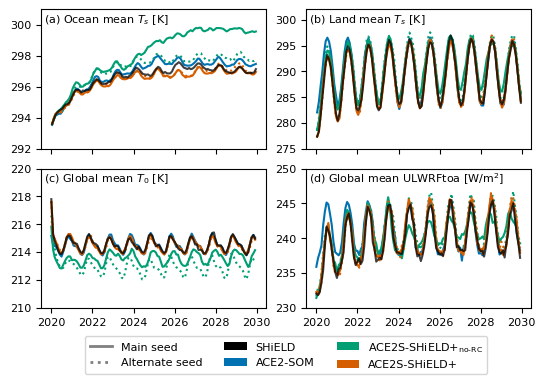

In [16]:
PLOTTED_MODELS = [
    "SHiELD-SOM",
    "ACE2-SOM baseline",
    "no-random-co2 energy-conserving rs0",
    "no-random-co2 energy-conserving rs1",
    "full energy-conserving rs0",
    "full energy-conserving rs1"
]
ALTERNATE_MODELS = {
    "no-random-co2 energy-conserving rs1",
    "full energy-conserving rs1"
}

plotting.configure_style()

fig, (ax1, ax2, ax3, ax4) = faceted.faceted(2, 2, width=5.5, aspect=0.618, sharey=False, internal_pad=(0.4, 0.2), left_pad=0.35, bottom_pad=0.72)

for model in PLOTTED_MODELS:
    color = COLORS[model]
    zorder = 10 if model == "SHiELD-SOM" else 0
    alpha = 0.75 if model == "SHiELD-SOM" else 1.0
    ls = ":" if model in ALTERNATE_MODELS else "-"
    label = textwrap.fill(LABELS[model], width=70)
    beaker_ds.surface_temperature.sel(region="ocean").sel(model=model).plot(ax=ax1, label=label, x="valid_time", color=color, zorder=zorder, alpha=alpha, ls=ls)
    beaker_ds.surface_temperature.sel(region="land").sel(model=model).plot(ax=ax2, label=label, x="valid_time", color=color, zorder=zorder, alpha=alpha, ls=ls)
    wandb_ds.air_temperature_0.sel(model=model).plot(ax=ax3, label=label, color=color, zorder=zorder, alpha=alpha, ls=ls)
    wandb_ds.ULWRFtoa.sel(model=model).plot(ax=ax4, label=label, color=color, zorder=zorder, alpha=alpha, ls=ls)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_xticks(xr.date_range("2020", freq="2YS", periods=6))

ax1.annotate(
    "(a) Ocean mean $T_s$ [K]", 
    xy=(0, 1), 
    xytext=(2, -2), 
    va="top", 
    xycoords="axes fraction",
    textcoords="offset points"
)
ax2.annotate(
    "(b) Land mean $T_s$ [K]", 
    xy=(0, 1), 
    xytext=(2, -2), 
    va="top", 
    xycoords="axes fraction",
    textcoords="offset points"
)
ax3.annotate(
    "(c) Global mean $T_0$ [K]", 
    xy=(0, 1), 
    xytext=(2, -2), 
    va="top", 
    xycoords="axes fraction",
    textcoords="offset points"
)
ax4.annotate(
    "(d) Global mean ULWRFtoa [W/m$^2$]", 
    xy=(0, 1), 
    xytext=(2, -2), 
    va="top", 
    xycoords="axes fraction",
    textcoords="offset points"
)

line_data = {
    "Main seed": ("gray", "-"),
    "Alternate seed": ("gray", ":"),
}

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]
patch_colors = {
    "SHiELD": ("k", 1.0),
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}

from matplotlib.patches import Patch

patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

central_x_position = plotting.get_central_position_between_axes((ax1, ax2, ax3, ax4), "x")
fig.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), loc="lower center", bbox_to_anchor=(central_x_position, 0.0), ncol=3, fontsize=8)

# ax4.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), bbox_to_anchor=(-1.0, -0.15), bbox_transform=ax4.transAxes, loc="upper left", ncol=3, fontsize=8)

ax1.set_ylim(292, 301)
ax2.set_ylim(275, 302)
ax3.set_ylim(210, 220)
ax4.set_ylim(230, 250)
fig.patch.set_alpha(0.0)
fig.savefig("figure-13.png", dpi=300)
fig.savefig("figure-13.pdf")